El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales donde se emplean filtros de 3x3 y 5x5 en cada capa y se concatenan las salida para la entrada a la capa siguiente

Importación de librerías

In [7]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
import matplotlib.pyplot as plt

Funciones

In [8]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [9]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [10]:
# Directorio con imagenes en tamaño original y tamaño reducido
d_original = 'E:/bandas/banda13/ene_01_mes'
d_reducida = 'E:/bandas/banda13/ene_01_reducida_mes'

# Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')]) # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

# Parámetro de secuencia temporal
timesteps = 3  # Puedes ajustar este valor

# Construir secuencias para ConvLSTM: X_seq (N, timesteps, H, W, C), y_seq (N, H, W, C)
X_base = np.array(images)[..., np.newaxis]  # (num_imgs, H, W, C)
y_base = X_base.copy()  # y_base igual a X_base, pero se usará para target

N_seq = X_base.shape[0] - timesteps
X_seq = np.array([X_base[i:i+timesteps] for i in range(N_seq)])  # (N_seq, timesteps, H, W, C)
y_seq = y_base[timesteps:]  # (N_seq, H, W, C)

print(f"Forma de X_seq: {X_seq.shape}")  # (N_seq, timesteps, H, W, C)
print(f"Forma de y_seq: {y_seq.shape}")  # (N_seq, H, W, C)

Procesando 741 imágenes
Forma de X_seq: (738, 3, 480, 480, 1)
Forma de y_seq: (738, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [11]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, ConvLSTM2D, Conv2D, TimeDistributed,
    Concatenate, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model

# Parámetros
timesteps = 3 # A partir de análisis de correlación
H, W, C = X_seq.shape[2], X_seq.shape[3], X_seq.shape[4]  # (height, width, channels) suponiendo X.shape = (N, T, H, W, C)
semilla = 42
tf.random.set_seed(semilla)

inputs = Input(shape=(timesteps, H, W, C), name='input_sequence')

# === Bloque 1: ConvLSTM multiescala ===
x1_3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True, activation=None)(inputs)
x1_3 = TimeDistributed(BatchNormalization())(x1_3)
x1_3 = Activation('relu')(x1_3)

x1_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(inputs)
x1_5 = TimeDistributed(BatchNormalization())(x1_5)
x1_5 = Activation('relu')(x1_5)

res1 = Concatenate(axis=-1)([x1_3, x1_5])  # (batch, t, H, W, 32)

# === Bloque 2 ===
x2_3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True, activation=None)(res1)
x2_3 = TimeDistributed(BatchNormalization())(x2_3)
x2_3 = Activation('relu')(x2_3)

x2_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(res1)
x2_5 = TimeDistributed(BatchNormalization())(x2_5)
x2_5 = Activation('relu')(x2_5)

res2 = Concatenate(axis=-1)([x2_3, x2_5])  # (batch, t, H, W, 32)
res2 = Add()([res2, res1])                 # Residual sum
res2 = Activation('relu')(res2)

# === Bloque 3 ===
x3_3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True, activation=None)(res2)
x3_3 = TimeDistributed(BatchNormalization())(x3_3)
x3_3 = Activation('relu')(x3_3)

x3_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(res2)
x3_5 = TimeDistributed(BatchNormalization())(x3_5)
x3_5 = Activation('relu')(x3_5)

res3 = Concatenate(axis=-1)([x3_3, x3_5])  # (batch, t, H, W, 32)
res3 = Add()([res3, res2])
res3 = Activation('relu')(res3)

# ===  Bloque 4 (proyección multicanal) ===
x4_3 = ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True, activation=None)(res3)
x4_3 = TimeDistributed(BatchNormalization())(x4_3)
x4_3 = Activation('relu')(x4_3)

x4_5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True, activation=None)(res3)
x4_5 = TimeDistributed(BatchNormalization())(x4_5)
x4_5 = Activation('relu')(x4_5)

res_final = Concatenate(axis=-1)([x4_3, x4_5])  # (batch, t, H, W, 48)

# === Proyección residual para igualar canales (1x1 temporalmente consistente) ===
res3_proj = ConvLSTM2D(48, (1, 1), padding='same', return_sequences=True, activation=None)(res3)
res3_proj = TimeDistributed(BatchNormalization())(res3_proj)

res_final = Add()([res_final, res3_proj])
res_final = Activation('relu')(res_final)

# ===  Salida ===
outputs = ConvLSTM2D(1, (1, 1), padding='same', activation='linear', return_sequences=False)(res_final)

model13= Model(inputs=inputs, outputs=outputs, name='ConvLSTM_residual_multiscale')

# Compilación
model13.compile(
    optimizer='adam',
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo:")
model13.summary()

# Callbacks
checkpoint = ModelCheckpoint(
    filepath="modelo13.h5",
    monitor="loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Entrenamiento
# Asignar X y y correctamente
X = X_seq
y = y_seq

print("Iniciando entrenamiento")
history13 = model13.fit(
    X, y,
    epochs=25,
    batch_size=4,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history13.history['loss'][-1]:.4f}")


Resumen del modelo:


Model: "ConvLSTM_residual_multiscale"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 3, 480,    │          0 │ -                 │
│ (InputLayer)        │ 480, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_10      │ (None, 3, 480,    │      9,856 │ input_sequence[0… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_11      │ (None, 3, 480,    │     27,264 │ input_sequence[0… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 3, 480,    │         64 │ conv_lstm2d_10[0… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 3, 480,    │         64 │ conv_lstm2d_11[0… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 3, 480,    │          0 │ activation_11[0]… │
│ (Concatenate)       │ 480, 32)          │            │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_12      │ (None, 3, 480,    │     27,712 │ concatenate_4[0]… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_13      │ (None, 3, 480,    │     76,864 │ concatenate_4[0]… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_11 │ (None, 3, 480,    │         64 │ conv_lstm2d_12[0… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_12 │ (None, 3, 480,    │         64 │ conv_lstm2d_13[0… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 3, 480,    │          0 │ activation_13[0]… │
│ (Concatenate)       │ 480, 32)          │            │ activation_14[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 3, 480,    │          0 │ concatenate_5[0]… │
│                     │ 480, 32)          │            │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 3, 480,    │          0 │ add_3[0][0]     

 Total params: 413,512 (1.58 MB)

 Trainable params: 413,128 (1.58 MB)

...

185/185 ━━━━━━━━━━━━━━━━━━━━ 2379s 13s/step - loss: 0.0074 - mean_absolute_percentage_error: 1216.8635 - root_mean_squared_error: 0.0860
Epoch 22/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0074 - mean_absolute_percentage_error: 1269.6428 - root_mean_squared_error: 0.0863 
Epoch 22: loss improved from 0.00740 to 0.00734, saving model to modelo13.h5


185/185 ━━━━━━━━━━━━━━━━━━━━ 2377s 13s/step - loss: 0.0073 - mean_absolute_percentage_error: 1213.1901 - root_mean_squared_error: 0.0857
Epoch 23/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0074 - mean_absolute_percentage_error: 1268.5944 - root_mean_squared_error: 0.0859 
Epoch 23: loss improved from 0.00734 to 0.00727, saving model to modelo13.h5


185/185 ━━━━━━━━━━━━━━━━━━━━ 2375s 13s/step - loss: 0.0073 - mean_absolute_percentage_error: 1211.6597 - root_mean_squared_error: 0.0853
Epoch 24/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0073 - mean_absolute_percentage_error: 1260.7555 - root_mean_squared_error: 0.0857 
Epoch 24: loss improved from 0.00727 to 0.00727, saving model to modelo13.h5


185/185 ━━━━━━━━━━━━━━━━━━━━ 2384s 13s/step - loss: 0.0073 - mean_absolute_percentage_error: 1205.7339 - root_mean_squared_error: 0.0853
Epoch 25/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 0.0073 - mean_absolute_percentage_error: 1261.1178 - root_mean_squared_error: 0.0853 
Epoch 25: loss improved from 0.00727 to 0.00719, saving model to modelo13.h5


185/185 ━━━━━━━━━━━━━━━━━━━━ 2382s 13s/step - loss: 0.0072 - mean_absolute_percentage_error: 1201.1696 - root_mean_squared_error: 0.0848
¡Entrenamiento completado!
Pérdida final: 0.0072


Valores de las metricas

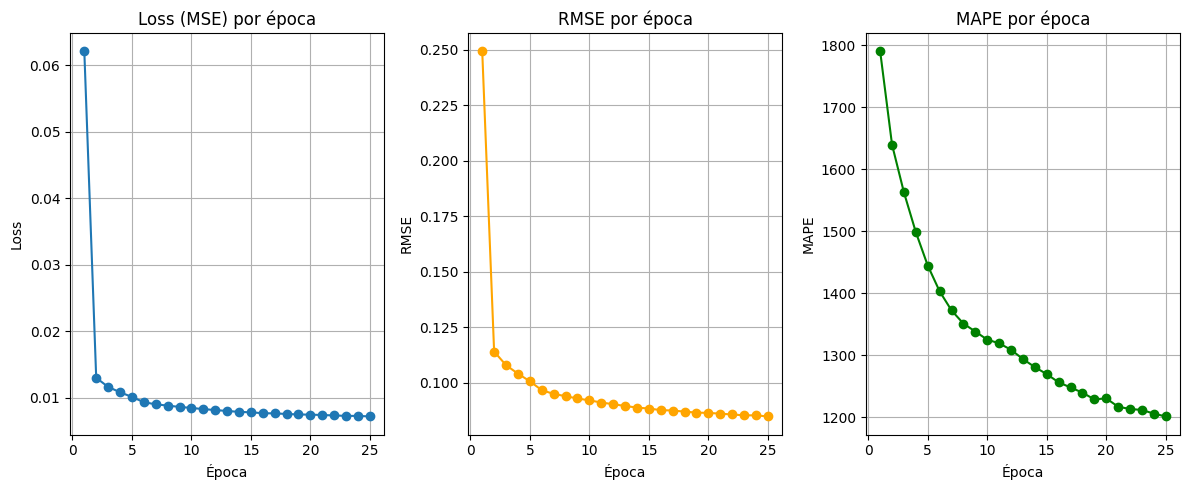

In [12]:
import matplotlib.pyplot as plt

# Extraer métricas del historial
loss = history13.history['loss']
rmse = history13.history['root_mean_squared_error']
mape = history13.history['mean_absolute_percentage_error']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o')
plt.title('Loss (MSE) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange')
plt.title('RMSE por época')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green')
plt.title('MAPE por época')
plt.xlabel('Época')
plt.ylabel('MAPE')
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model13.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 659s 26s/step - loss: 1.2124 - mean_absolute_percentage_error: 1051.4077 - root_mean_squared_error: 1.1011
Pérdida (MSE): 1.2124
RMSE: 1.1011
MAPE: 1051.4077


Visualización de imagenes

In [ ]:
# Genera las predicciones
y_pred13 = model13.predict(X)

# Seleccionar el último frame de la secuencia (t) como entrada para visualizar,
# ya que X tiene forma (N, timesteps, H, W, C) y mostrar_resultados espera (N, H, W, C)
mostrar_resultados(
    X[:, -1, ...],  # último timestep
    y,
    y_pred13,
    n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 13 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

 5/24 ━━━━━━━━━━━━━━━━━━━━ 9:22 30s/step

Validación

In [ ]:
# Directorio original y reducido
d_feb_1s = 'E:/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = 'E:/bandas/banda13/feb_01_07_1s_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_val = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_val = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_val]
images_val = [np.clip(img, 0, 1) for img in images_val]  # Limita los valores al rango [0, 1]

X_val = np.array(images_val[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_val = np.array(images_val[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_val.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_val.shape}")  # Imprime la forma del array de salida

Procesando 167 imágenes
Forma de X: (166, 480, 480, 1)
Forma de y: (166, 480, 480, 1)


Metricas de validación

In [ ]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model13.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.0155 - mean_absolute_percentage_error: 907.0707 - root_mean_squared_error: 0.1246
Pérdida (MSE): 0.0155
RMSE: 0.1246
MAPE: 907.0707


Visualización de imagenes con conjunto de validación

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


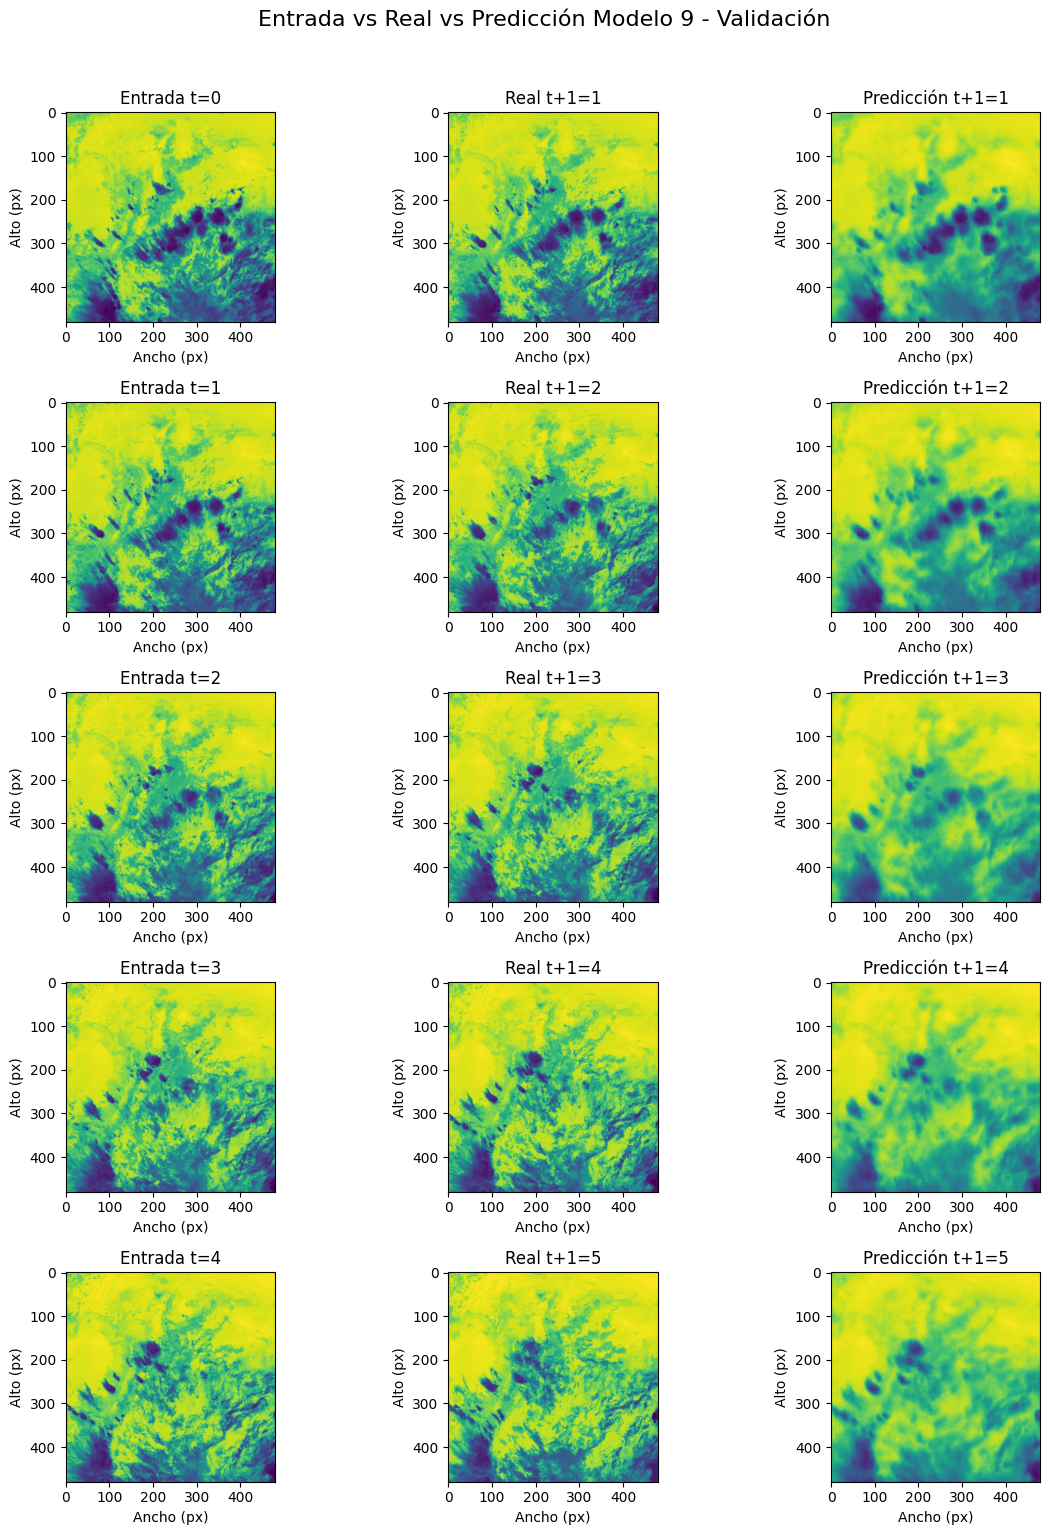

In [ ]:
y_pred13_val = model13.predict(X_val)  # Genera las predicciones
mostrar_resultados(
    X_val, y_val, y_pred13_val, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 13 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

In [ ]:

# Extraer métricas de entrenamiento del historial
loss = history13.history['loss']
rmse = history13.history['root_mean_squared_error']
mape = history13.history['mean_absolute_percentage_error']
epochs = range(1, len(loss) + 1)

# Obtener métricas de validación evaluando el modelo en el conjunto de validación
# Asegúrate de que X_val y y_val están definidos y cargados
loss_val, rmse_val, mape_val = model13.evaluate(X_val, y_val, verbose=0) # verbose=0 para no imprimir el progreso

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento')
plt.axhline(y=loss_val, color='r', linestyle='-', label='Validación (final)')
plt.title('Loss (MSE) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento')
plt.axhline(y=rmse_val, color='red', linestyle='-', label='Validación (final)')
plt.title('RMSE por época')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento')
plt.axhline(y=mape_val, color='red', linestyle='-', label='Validación (final)')
plt.title('MAPE por época')
plt.xlabel('Época')
plt.ylabel('MAPE')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()